In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Cargar datos

In [2]:
db_path = Path("database.sqlite")
assert db_path.exists(), f"No se encuentra la base de datos en {db_path}"

conn = sqlite3.connect(db_path)
print("Conexión a la base de datos OK")

Conexión a la base de datos OK


In [3]:
# Cargar tablas principales desde SQLite
query_country   = "SELECT * FROM Country;"
query_league    = "SELECT * FROM League;"
query_match     = "SELECT * FROM Match;"
query_player    = "SELECT * FROM Player;"
query_team      = "SELECT * FROM Team;"
query_player_attr = "SELECT * FROM Player_Attributes;"

country = pd.read_sql(query_country, conn)
league  = pd.read_sql(query_league,  conn)
match   = pd.read_sql(query_match,   conn)
player  = pd.read_sql(query_player,  conn)
team    = pd.read_sql(query_team,    conn)
player_attr = pd.read_sql(query_player_attr, conn)

# Inspeccionar tamaños
print("Country:", country.shape)
print("League:",  league.shape)
print("Match:",   match.shape)
print("Player:",  player.shape)
print("Team:",    team.shape)
print("Player_Attributes:", player_attr.shape)

Country: (11, 2)
League: (11, 3)
Match: (25979, 115)
Player: (11060, 7)
Team: (299, 5)
Player_Attributes: (183978, 42)


In [4]:
match.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,away_player_Y9,away_player_Y10,away_player_Y11,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,goal,shoton,shotoff,foulcommit,card,cross,corner,possession,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.73,3.40,5.00,1.75,3.35,4.20,1.85,3.2,3.5,1.80,3.3,3.75,NaN,NaN,NaN,1.70,3.30,4.33,1.90,3.3,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.95,3.20,3.60,1.80,3.30,3.95,1.90,3.2,3.5,1.90,3.2,3.50,NaN,NaN,NaN,1.83,3.30,3.60,1.95,3.3,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.38,3.30,2.75,2.40,3.30,2.55,2.60,3.1,2.3,2.50,3.2,2.50,NaN,NaN,NaN,2.50,3.25,2.40,2.63,3.3,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.44,3.75,7.50,1.40,4.00,6.80,1.40,3.9,6.0,1.44,3.6,6.50,NaN,NaN,NaN,1.44,3.75,6.00,1.44,4.0,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,3.50,1.65,5.00,3.50,1.60,4.00,3.3,1.7,4.00,3.4,1.72,NaN,NaN,NaN,4.20,3.40,1.70,4.50,3.5,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [ ]:
# Ver nombres de columnas de 'match'
match_cols = list(match.columns)

print("Columnas de `match` (ejemplo):")
print(match_cols[:10])

# Verificar las columnas de jugadores y equipos
team_home_col = [c for c in match_cols if "home_team_api_id" in c]
team_away_col = [c for c in match_cols if "away_team_api_id" in c]

home_player_cols = [c for c in match_cols if c.startswith("home_player_")]
away_player_cols = [c for c in match_cols if c.startswith("away_player_")]

print("Columna home team:", team_home_col)
print("Columna away team:", team_away_col)
print("home_player_* cols:", home_player_cols[:11])
print("away_player_* cols:", away_player_cols[:11])

Columnas de `match` (ejemplo):
['id', 'country_id', 'league_id', 'season', 'stage', 'date', 'match_api_id', 'home_team_api_id', 'away_team_api_id', 'home_team_goal']
Columna home team: ['home_team_api_id']
Columna away team: ['away_team_api_id']
home_player_* cols: ['home_player_X1', 'home_player_X2', 'home_player_X3', 'home_player_X4', 'home_player_X5', 'home_player_X6', 'home_player_X7', 'home_player_X8', 'home_player_X9', 'home_player_X10', 'home_player_X11']
away_player_* cols: ['away_player_X1', 'away_player_X2', 'away_player_X3', 'away_player_X4', 'away_player_X5', 'away_player_X6', 'away_player_X7', 'away_player_X8', 'away_player_X9', 'away_player_X10', 'away_player_X11']


## Unimos jugadores con partidos

In [ ]:
home_player_cols = [f"home_player_{i}" for i in range(1, 12)]
away_player_cols = [f"away_player_{i}" for i in range(1, 12)]

players_per_match = []

for _, row in match[["id", "season"] + home_player_cols + away_player_cols].iterrows():
    # Jugadores locales
    for i in range(1, 12):
        col = f"home_player_{i}"
        p = row[col]
        if pd.notna(p):
            players_per_match.append({
                "match_id": row["id"],
                "season": row["season"],
                "is_home": 1,
                "player_api_id": int(p),
            })
    # Jugadores visitantes
    for i in range(1, 12):
        col = f"away_player_{i}"
        p = row[col]
        if pd.notna(p):
            players_per_match.append({
                "match_id": row["id"],
                "season": row["season"],
                "is_home": 0,
                "player_api_id": int(p),
            })

players_per_match = pd.DataFrame(players_per_match)
print("players_per_match shape:", players_per_match.shape)
players_per_match.head()

players_per_match shape: (542281, 4)


,match_id,season,is_home,player_api_id
0,145,2008/2009,1,39890
1,145,2008/2009,1,38788
2,145,2008/2009,1,38312
3,145,2008/2009,1,26235
4,145,2008/2009,1,26916


## Añadir atributos de jugadores 

In [ ]:
# Tomar el último registro de atributos por jugador
query_latest_attr = """
SELECT player_api_id, overall_rating, potential
FROM Player_Attributes
WHERE date = (
    SELECT MAX(date)
    FROM Player_Attributes pa2
    WHERE pa2.player_api_id = Player_Attributes.player_api_id
)
"""

latest_attr = pd.read_sql(query_latest_attr, conn)

# Unir con la tabla de jugadores básica
players_with_attr = player[["player_api_id", "player_name"]].merge(
    latest_attr, on="player_api_id", how="left"
)

players_with_attr["overall_rating"] = players_with_attr["overall_rating"].fillna(
    players_with_attr["overall_rating"].median()
)

players_with_attr["potential"] = players_with_attr["potential"].fillna(
    players_with_attr["potential"].mean()
)

players_with_attr.head()

,player_api_id,player_name,overall_rating,potential
0,505942,Aaron Appindangoye,67.0,71.0
1,155782,Aaron Cresswell,74.0,76.0
2,162549,Aaron Doran,65.0,67.0
3,30572,Aaron Galindo,69.0,69.0
4,23780,Aaron Hughes,70.0,70.0


## Unir jugadores con partidos y equipos

In [ ]:
match_relevant = match[
    ["id", "season", "date", "home_team_api_id", "away_team_api_id"]
].copy()

# Unir jugadores con partidos
players_season = players_per_match.merge(
    match_relevant, left_on="match_id", right_on="id", how="left"
)

# Añadir atributos de jugadores (rating y potencial)
players_season = players_season.merge(
    players_with_attr[["player_api_id", "overall_rating", "potential"]],
    on="player_api_id", how="left"
)

# Formatear fecha y ordenar
players_season["date"] = pd.to_datetime(players_season["date"])
players_season = players_season.sort_values(["player_api_id", "date"])

players_season.head()

,match_id,season_x,is_home,player_api_id,id,season_y,date,home_team_api_id,away_team_api_id,overall_rating,potential
335611,15797,2008/2009,1,2625,15797,2008/2009,2009-03-01,8569,2182,61.0,61.0
335647,15802,2008/2009,0,2625,15802,2008/2009,2009-03-07,8028,8569,61.0,61.0
335722,15818,2008/2009,1,2625,15818,2008/2009,2009-03-14,8569,10265,61.0,61.0
335868,15832,2008/2009,0,2625,15832,2008/2009,2009-03-21,8244,8569,61.0,61.0
335904,15837,2008/2009,1,2625,15837,2008/2009,2009-04-03,8569,8025,61.0,61.0


## Calcular partidos de jugador por temporada

In [ ]:
# Partidos jugados por jugador y temporada

partidos_temp = (
    players_season
    .groupby(["player_api_id", "season_x"], as_index=False)
    .size()
    .rename(columns={"season_x": "season", "size": "matches_played"})
)

partidos_temp.head()

,player_api_id,season,matches_played
0,2625,2008/2009,12
1,2625,2009/2010,30
2,2625,2010/2011,7
3,2625,2011/2012,15
4,2625,2012/2013,8


## Calcular racha máxima de partidos seguidos

In [ ]:
# Ordenar por jugador y fecha
tmp = players_season[["player_api_id", "season_y", "date"]].copy()
tmp = tmp.sort_values(["player_api_id", "season_y", "date"])

# Calcular diferencia de días entre partidos consecutivos
tmp["date_shifted"] = tmp.groupby(["player_api_id", "season_y"])["date"].shift(1)
tmp["days_diff"] = (tmp["date"] - tmp["date_shifted"]).dt.days

# Racha: si hay menos de 7 días, continúa; si no, se reinicia
tmp["is_close"] = (tmp["days_diff"] <= 7).astype(int)
tmp["streak"] = tmp.groupby(["player_api_id", "season_y"])["is_close"].cumsum()

# Máxima racha por jugador y temporada
max_streak_by_player = (
    tmp.groupby(["player_api_id", "season_y"])["streak"].max()
    .reset_index()
    .rename(columns={"season_y": "season", "streak": "max_streak"})
)

max_streak_by_player.head()

,player_api_id,season,max_streak
0,2625,2008/2009,8
1,2625,2009/2010,17
2,2625,2010/2011,3
3,2625,2011/2012,4
4,2625,2012/2013,4


## Construir variables de riesgo de lesión por jugador y temporada

In [ ]:
# 1) Añadir columna "season" a partidos_temp
partidos_temp = partidos_temp.rename(columns={"season": "season"}).copy()

# 2) Añadir rating del jugador
risk_features = partidos_temp.merge(
    max_streak_by_player, on=["player_api_id", "season"], how="left"
).merge(
    players_with_attr[["player_api_id", "overall_rating"]],
    on="player_api_id", how="left"
)

# 3) Añadir densidad de partidos por temporada
risk_features["season_start"] = pd.to_datetime(
    "07-01-" + risk_features["season"].str.split("/").str[0],
    format="%m-%d-%Y"
)
risk_features["season_end"] = pd.to_datetime(
    "06-30-" + risk_features["season"].str.split("/").str[1],
    format="%m-%d-%Y"
)
risk_features["season_days"] = (
    risk_features["season_end"] - risk_features["season_start"]
).dt.days
risk_features["matches_per_day"] = (
    risk_features["matches_played"] / risk_features["season_days"]
)

# 4) Rellenar nulos
risk_features["max_streak"] = risk_features["max_streak"].fillna(0)
risk_features["overall_rating"] = risk_features["overall_rating"].fillna(
    risk_features["overall_rating"].median()
)

risk_features.head()

,player_api_id,season,matches_played,max_streak,overall_rating,season_start,season_end,season_days,matches_per_day
0,2625,2008/2009,12,8,61.0,2008-07-01,2009-06-30,364,0.032967
1,2625,2009/2010,30,17,61.0,2009-07-01,2010-06-30,364,0.082418
2,2625,2010/2011,7,3,61.0,2010-07-01,2011-06-30,364,0.019231
3,2625,2011/2012,15,4,61.0,2011-07-01,2012-06-30,365,0.041096
4,2625,2012/2013,8,4,61.0,2012-07-01,2013-06-30,364,0.021978


## Simular etiqueta de lesión (alto / bajo riesgo)

In [ ]:
# 1) Normalizar  variables
risk_features["matches_played_std"] = (
    risk_features["matches_played"] - risk_features["matches_played"].mean()
) / risk_features["matches_played"].std()

risk_features["max_streak_std"] = (
    risk_features["max_streak"] - risk_features["max_streak"].mean()
) / risk_features["max_streak"].std()

# 2) Puntaje de riesgo (carga + racha)
risk_features["injury_score"] = (
    0.5 * risk_features["matches_played_std"] +
    0.5 * risk_features["max_streak_std"]
)

# 3) Umbral heurístico: 80 % de los jugadores con más riesgo
threshold = np.percentile(risk_features["injury_score"], 80)
risk_features["injury_risk"] = (risk_features["injury_score"] > threshold).astype(int)

risk_features["injury_risk"].value_counts(normalize=True)

injury_risk
0    0.804032
1    0.195968
Name: proportion, dtype: float64

## Dataset final para el modelo

In [18]:
# Variables de entrada
model_features = [
    "matches_played",
    "max_streak",
    "matches_per_day",
    "overall_rating"
]

X = risk_features[model_features].dropna()
y = risk_features.loc[X.index, "injury_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (26984, 4)
y_train shape: (26984,)


## Entrenar y evaluar el modelo de riesgo de lesión

In [19]:
# Entrenar Random Forest
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred, target_names=["Bajo riesgo", "Alto riesgo"]))

Accuracy: 1.0
AUC: 1.0
              precision    recall  f1-score   support

 Bajo riesgo       1.00      1.00      1.00      5424
 Alto riesgo       1.00      1.00      1.00      1322

    accuracy                           1.00      6746
   macro avg       1.00      1.00      1.00      6746
weighted avg       1.00      1.00      1.00      6746



## Matriz de confusión

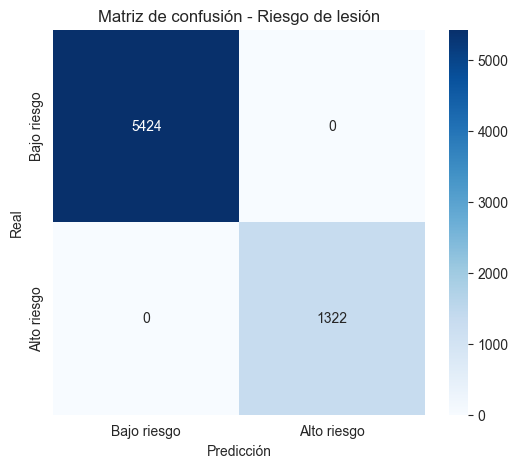

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Bajo riesgo", "Alto riesgo"],
    yticklabels=["Bajo riesgo", "Alto riesgo"]
)
plt.title("Matriz de confusión - Riesgo de lesión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

##  Importancia de variables

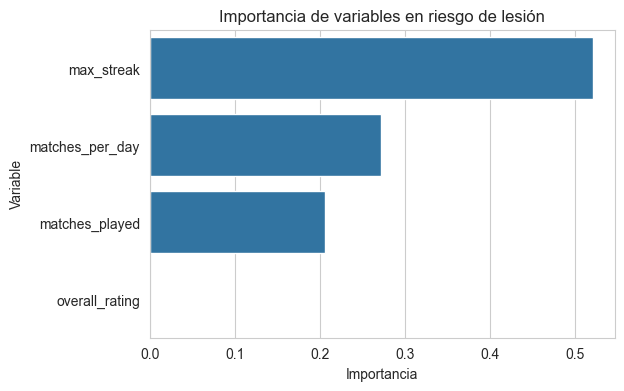

In [21]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importancia de variables en riesgo de lesión")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## Cierre de conexión

In [ ]:
conn.close()